<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Liz Multiple Linear Regression

Load data:

In [75]:
# Import Required Packages
import glob
import os
import zipfile
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import holidays
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn import preprocessing
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import curve_fit

In [5]:
# For use in Visual Studio

#Get all part files in order
part_files = sorted(glob.glob("data/NSW/forecastdemand_nsw.csv.zip.part*"))

# Combine them into one ZIP file
with open("data/NSW/forecastdemand_nsw.csv.zip", "wb") as output:
    for part in part_files:
        with open(part, "rb") as pf:
            output.write(pf.read())
print("Zip file reconstructed successfully")

Zip file reconstructed successfully


In [6]:
# Unzip the data files into the data folder

# List of zip files and destination folder
zip_files = [
    "data/NSW/forecastdemand_nsw.csv.zip",
    "data/NSW/temperature_nsw.csv.zip",
    "data/NSW/totaldemand_nsw.csv.zip"
]
destination_folder = "data"

# Unzip each file
for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Extracted: {zip_path} → {destination_folder}")
    except FileNotFoundError:
        print(f"File not found: {zip_path}")
    except zipfile.BadZipFile:
        print(f"Invalid ZIP file: {zip_path}")
    except Exception as e:
        print(f"Error extracting {zip_path}: {e}")


Extracted: data/NSW/forecastdemand_nsw.csv.zip → data
Extracted: data/NSW/temperature_nsw.csv.zip → data
Extracted: data/NSW/totaldemand_nsw.csv.zip → data


In [7]:
# Remove the ZIP file if it exists
zip_path = "data/NSW/forecastdemand_nsw.csv.zip"
try:
    os.remove(zip_path)
    print(f"Removed: {zip_path}")
except FileNotFoundError:
    print(f"File not found (skipped): {zip_path}")
except Exception as e:
    print(f"Error removing {zip_path}: {e}")

# List contents of the 'data' folder with file sizes
data_folder = "data"
try:
    print("\nContents of 'data' folder:")
    for filename in os.listdir(data_folder):
        filepath = os.path.join(data_folder, filename)
        if os.path.isfile(filepath):
            size_kb = os.path.getsize(filepath) / 1024
            print(f"{filename:<40} {size_kb:>10.2f} KB")
except Exception as e:
    print(f"Error listing files in {data_folder}: {e}")


Removed: data/NSW/forecastdemand_nsw.csv.zip

Contents of 'data' folder:
forecastdemand_nsw.csv                    722297.76 KB
temperature_nsw.csv                         6716.26 KB
totaldemand_nsw.csv                         5660.43 KB


In [8]:
# Create dataframes

df_forecast = pd.read_csv('data/forecastdemand_nsw.csv')
df_temperature = pd.read_csv('data/temperature_nsw.csv')
df_totaldemand = pd.read_csv('data/totaldemand_nsw.csv')

In [9]:
# Remove unzipped files to save space

# List of files to remove
files_to_remove = [
    "data/forecastdemand_nsw.csv",
    "data/temperature_nsw.csv",
    "data/totaldemand_nsw.csv"
]

# Remove each file if it exists
for file_path in files_to_remove:
    try:
        os.remove(file_path)
        print(f"Removed: {file_path}")
    except FileNotFoundError:
        print(f"File not found (skipped): {file_path}")
    except Exception as e:
        print(f"Error removing {file_path}: {e}")


Removed: data/forecastdemand_nsw.csv
Removed: data/temperature_nsw.csv
Removed: data/totaldemand_nsw.csv


Add additional data:

In [10]:
# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

Convert 30 minute data points into Daily data points:

In [11]:
# Convert all to pandas datetime and normalize to day-level

# Convert DATETIME column to pandas datetime
def convert_datetime(df):
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
    return df

# Apply conversion to all datasets
df_forecast = convert_datetime(df_forecast)
df_temperature = convert_datetime(df_temperature)
df_totaldemand = convert_datetime(df_totaldemand)


# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE

# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': 'mean',
    'TOTALDEMAND': 'mean'
})

# Create binary features for extreme temperature events
df_daily['extreme_hot'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['extreme_cold'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)


print(df_daily.head())




           TEMPERATURE                  FORECASTDEMAND  TOTALDEMAND  \
                   min   max       mean           mean         mean   
DATETIME                                                              
2010-01-01        22.1  28.8  25.185417    7723.688982  7801.352917   
2010-01-02        22.2  29.4  24.795833    7804.668591  8017.459792   
2010-01-03        17.9  21.5  19.462500    7491.520488  7399.899583   
2010-01-04        17.9  23.9  20.847917    8592.014274  8241.720208   
2010-01-05        15.4  27.7  22.660417    8907.999454  8827.813125   

           extreme_hot extreme_cold  
                                     
DATETIME                             
2010-01-01       False        False  
2010-01-02       False        False  
2010-01-03       False        False  
2010-01-04       False        False  
2010-01-05       False        False  


Create Model Features:

In [42]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'extreme_hot': df_daily['extreme_hot'],
    'extreme_cold': df_daily['extreme_cold']
})
# Target variable
y= df_daily['TOTALDEMAND']['mean'].values


# Rolling averages (3-day mean temperature)
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
X['temp_diff'] = X['temp_mean'] - X['temp_mean'].shift(1)
# Add day of week and month - feature engineering
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))

# One-hot encode day of week, month
X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=False)

# Feature matrix X and target y
feature_cols = ['temp_mean', 'temp_min', 'temp_max', 'temp_rolling3', 'temp_diff', 'extreme_hot', 'extreme_cold', 'is_holiday'] + \
               [col for col in X.columns if col.startswith('dayofweek_') or col.startswith('month_')]
X = X[feature_cols].fillna(0)

# Rename day and month columns for better clarity
# Mapping dictionaries
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Rename columns
X.rename(columns={
    **{f'dayofweek_{i}': day_map[i] for i in day_map},
    **{f'month_{i}': month_map[i] for i in month_map}
}, inplace=True)


print(X.head())
print(X.dtypes)

print(y[:5])

            temp_mean  temp_min  temp_max  temp_rolling3  temp_diff  \
DATETIME                                                              
2010-01-01  25.185417      22.1      28.8      25.185417   0.000000   
2010-01-02  24.795833      22.2      29.4      24.990625  -0.389583   
2010-01-03  19.462500      17.9      21.5      23.147917  -5.333333   
2010-01-04  20.847917      17.9      23.9      21.702083   1.385417   
2010-01-05  22.660417      15.4      27.7      20.990278   1.812500   

            extreme_hot  extreme_cold  is_holiday  Monday  Tuesday  ...  \
DATETIME                                                            ...   
2010-01-01        False         False        True   False    False  ...   
2010-01-02        False         False       False   False    False  ...   
2010-01-03        False         False       False   False    False  ...   
2010-01-04        False         False       False    True    False  ...   
2010-01-05        False         False       False   

Conduct some exploratory data analysis:

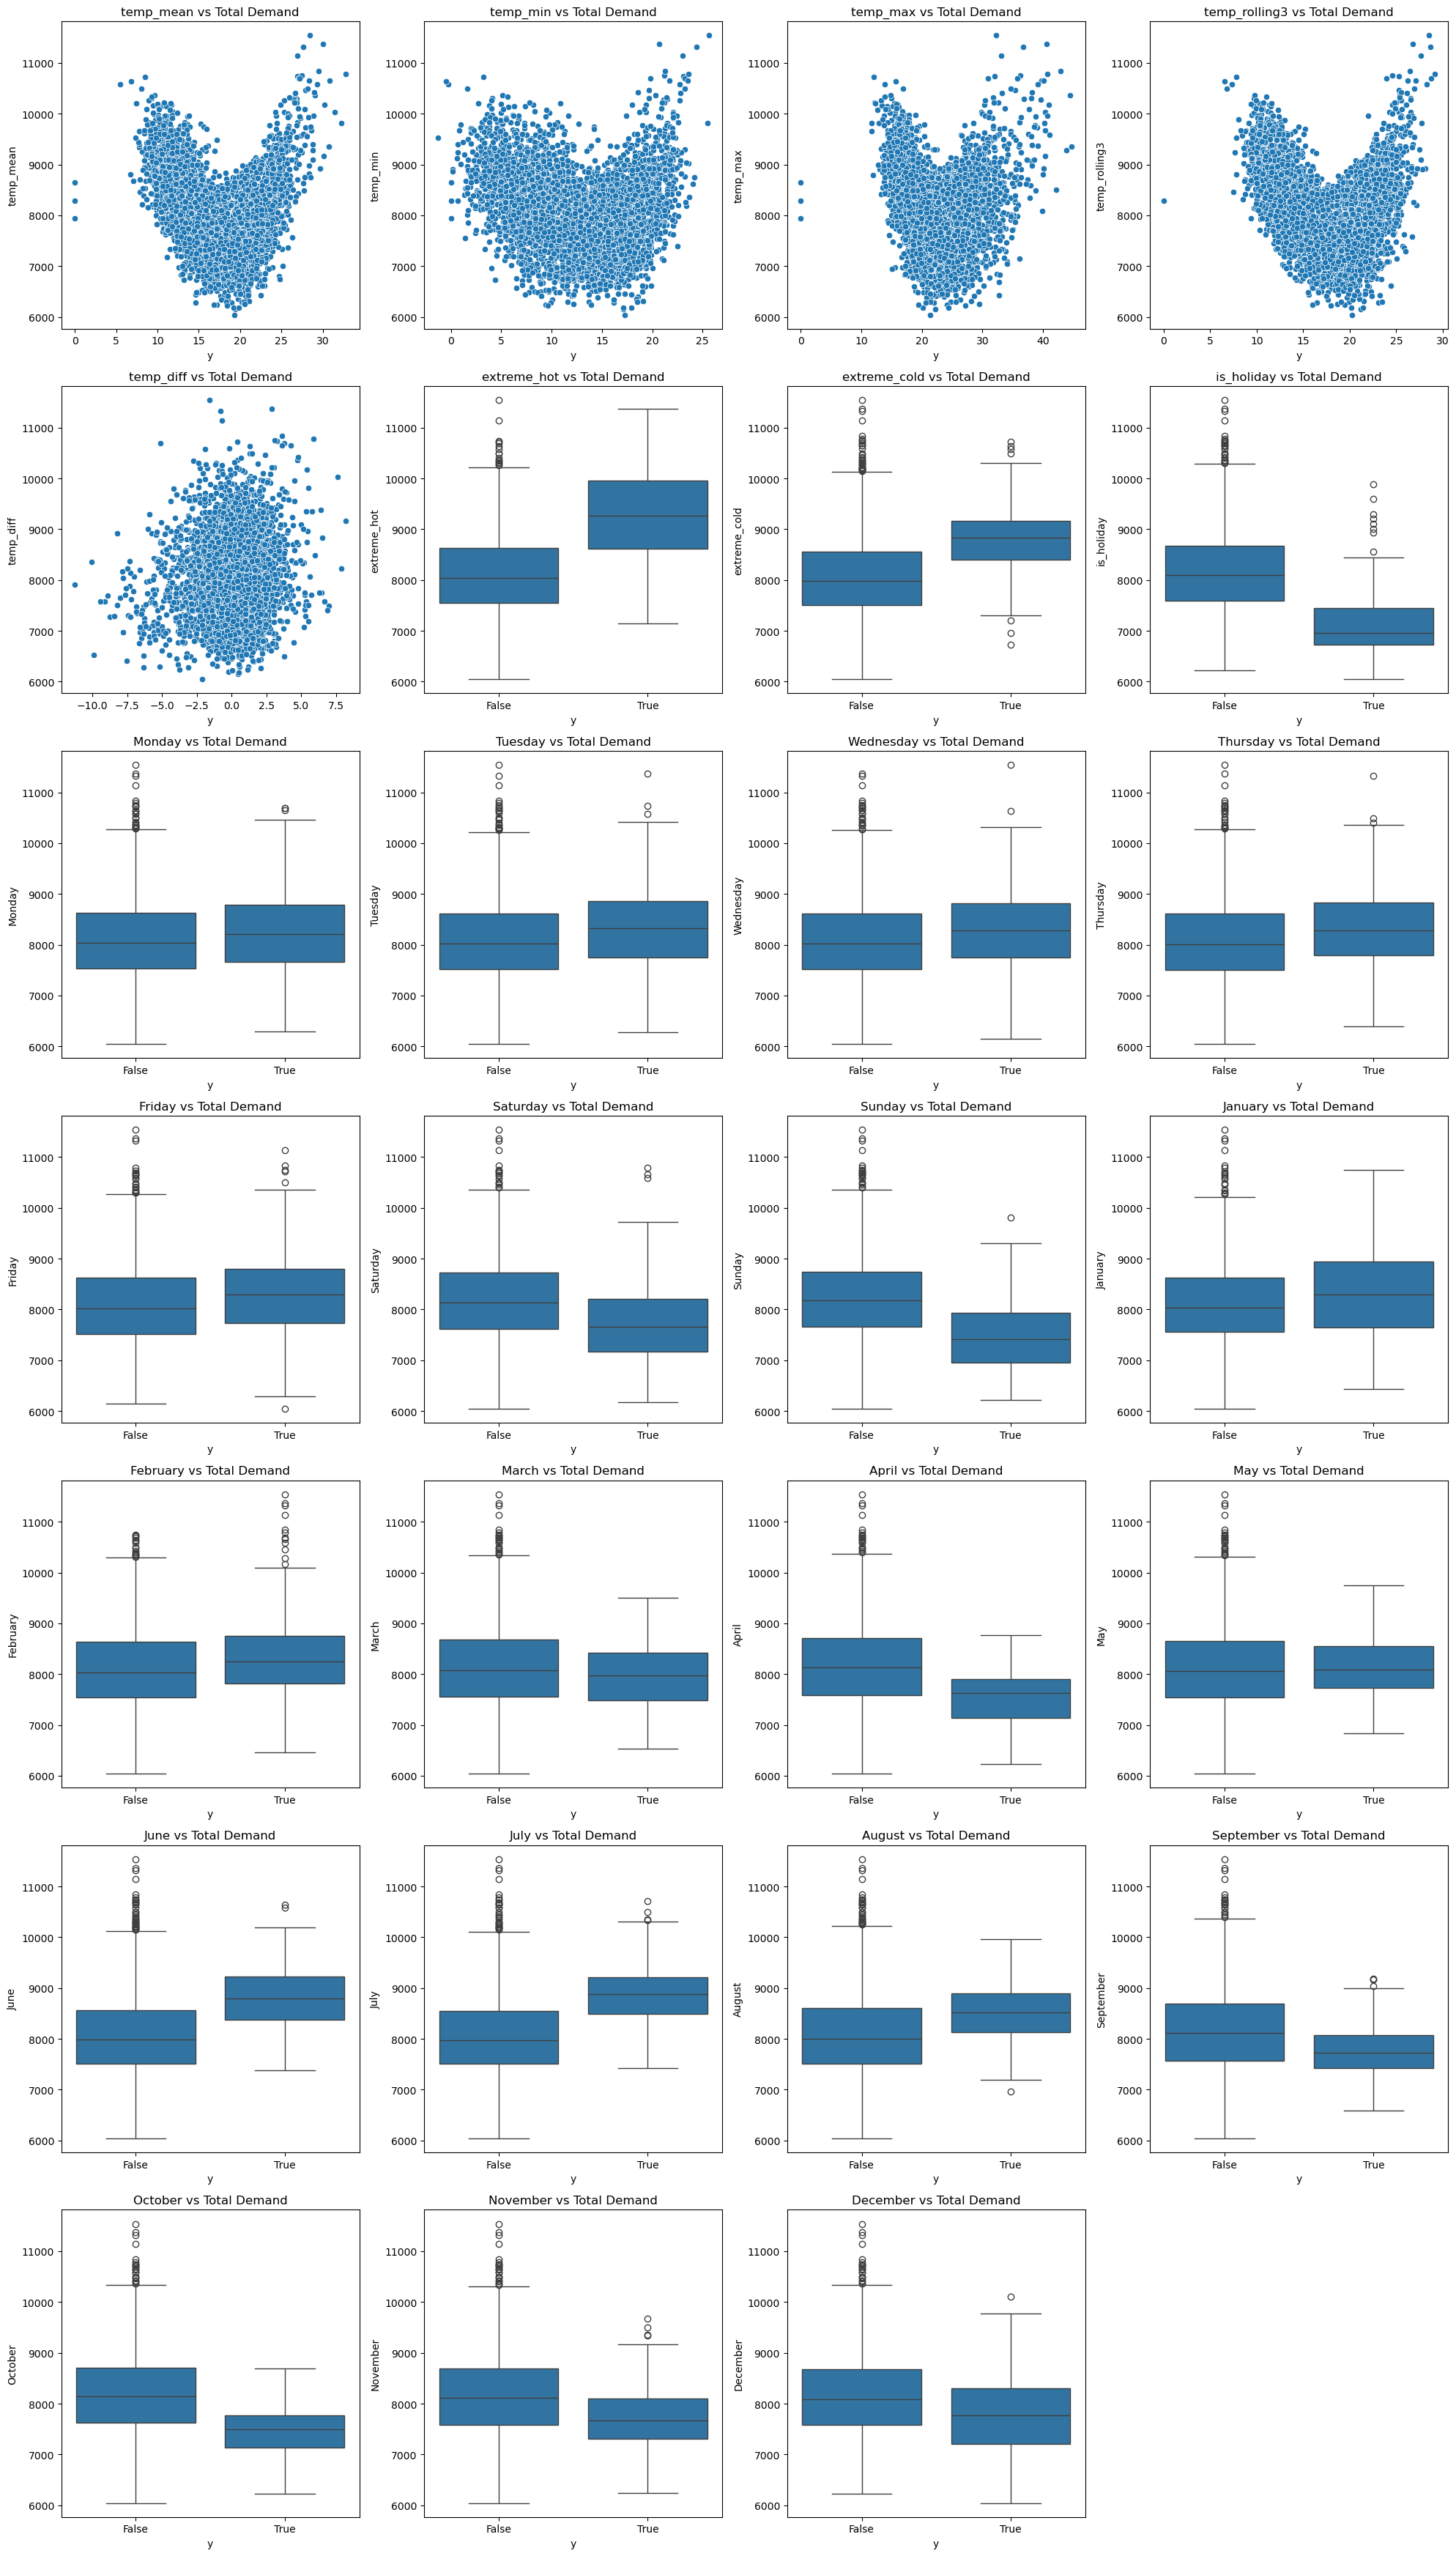

In [45]:
# Plot independent variables versus dependant variable

# Define float and boolean/categorical columns
float_cols = X.columns[:5]
bool_cols = X.columns[5:28]
all_cols = list(float_cols) + list(bool_cols)

# Total number of plots
n_plots = len(all_cols)

# Grid size
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each feature against y
for i, col in enumerate(all_cols):
    ax = axes[i]
    if col in float_cols:
        sns.scatterplot(x=X[col], y=y, ax=ax)
    else:
        sns.boxplot(x=X[col], ax=ax, y=y)
    ax.set_title(f'{col} vs Total Demand')
    ax.set_xlabel('y')
    ax.set_ylabel(col)

# Hide unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




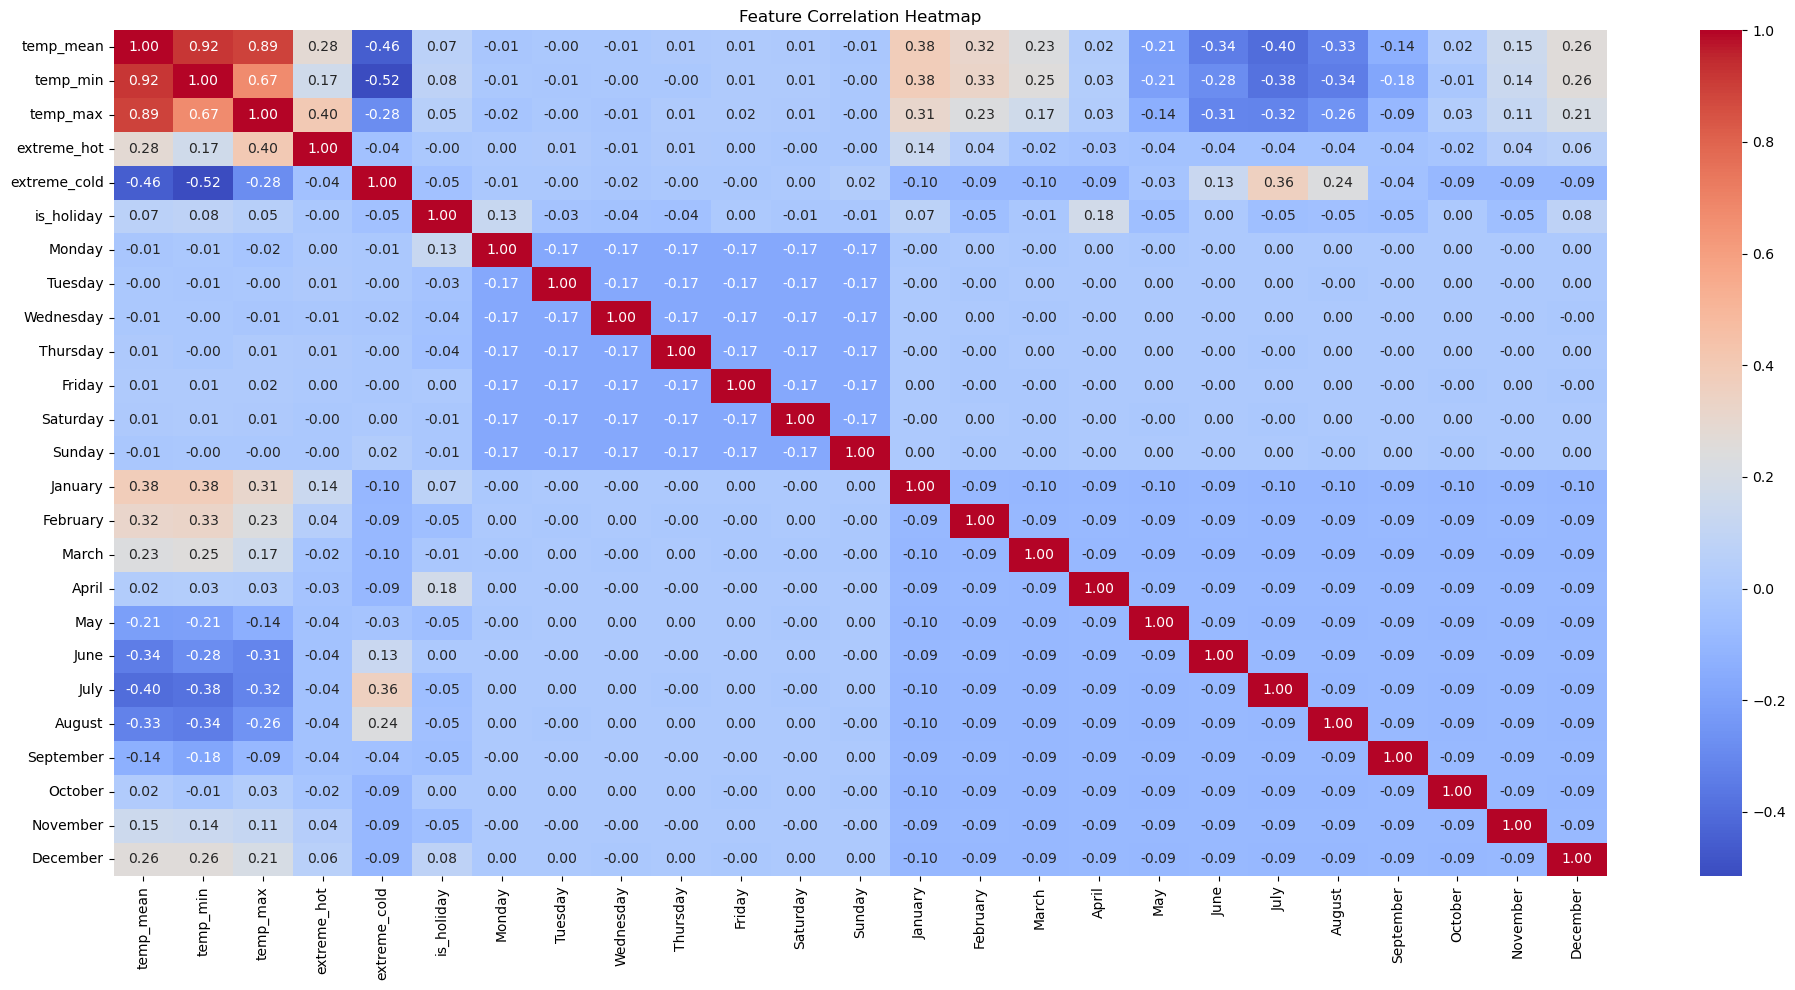

In [34]:
# Check Correlation Matrix

plt.figure(figsize=(20, 10))  
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



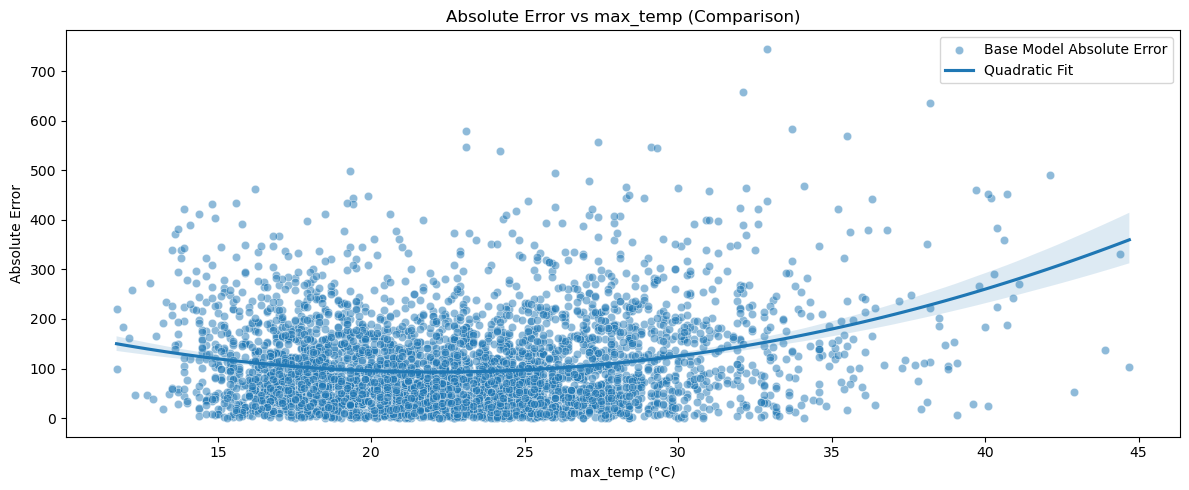

In [38]:
# Review current performance of base model "Forecast Demand"

# Absolute Error

df_daily.replace([np.inf, -np.inf], np.nan).dropna()


x = df_daily['TEMPERATURE']['max']
y = np.asarray(abs(df_daily['TOTALDEMAND'] - df_daily['FORECASTDEMAND'])).flatten()


# Standardize x
x_mean = x.mean()
x_std = x.std() or 1.0  # Avoid division by zero
x_scaled = (x - x_mean) / x_std
x_flat = np.asarray(x).flatten()


# Plot 
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x_flat, y=y, alpha=0.5, label = 'Base Model Absolute Error')
sns.regplot(x=x_flat, y=y, scatter=False, order=2, label = 'Quadratic Fit')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs max_temp (Comparison)")
plt.xlabel("max_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()



Mulitple Linear Regression:

In [62]:
# Create train and test dataset (70/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create linear regression model
model = LinearRegression()

# Fit the model
model.fit(X_train,y_train)

# Make predictions
y_pred = model.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred))
print(
  'R_squared : ', r2_score(y_test, y_pred))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Display
print(coef_table[['Feature', 'Coefficient']])



mean_squared_error :  257700.529813887
mean_absolute_error :  408.61675410756976
R_squared :  0.5890136761880116
          Feature  Coefficient
0       temp_mean     4.474673
1        temp_min    53.588563
2        temp_max    14.051300
3   temp_rolling3   -32.997207
4       temp_diff    -1.732724
5     extreme_hot  1193.007428
6    extreme_cold   405.332179
7      is_holiday  -818.060461
8          Monday   159.519594
9         Tuesday   224.796814
10      Wednesday   222.966010
11       Thursday   229.111690
12         Friday   190.065397
13       Saturday  -400.155740
14         Sunday  -626.303764
15        January     3.236482
16       February   -36.537898
17          March  -283.545770
18          April  -393.608035
19            May   165.050999
20           June   857.925710
21           July   889.638837
22         August   557.065208
23      September  -209.169669
24        October  -566.044466
25       November  -522.002536
26       December  -462.008863


In [ ]:
# Evaluation Plots



Multiple Linear Regression Model Using Recursive Feature Elimination:

In [69]:
# Fit RFE
rfe = RFE(model, n_features_to_select=10, step=0.5)
rfe.fit(X_train,y_train)

# Create DataFrame of rankings
rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': rfe.ranking_
}).sort_values(by='RFE_Rank')  

# Make predictions
y_pred2 = rfe.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred2))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred2))
print(
  'R_squared : ', r2_score(y_test, y_pred2))

# Print Coefficient table

# Get selected features and their coefficients
selected_features = X.columns[rfe.support_]
selected_coefs = model.coef_[rfe.support_]


# Create a DataFrame of coefficients
coef_table2 = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs
})

# Display
print(coef_table2[['Feature', 'Coefficient']])


# Feature Importance 
rfe_table = rfe_df.sort_values(by='RFE_Rank')
print("\n📋 Feature Importance via RFE Ranking:\n")
print(rfe_table.to_string(index=False))


mean_squared_error :  297864.28231964883
mean_absolute_error :  437.0573028439476
R_squared :  0.5249596635526521
       Feature  Coefficient
0  extreme_hot  1193.007428
1   is_holiday  -818.060461
2     Saturday  -400.155740
3       Sunday  -626.303764
4        April  -393.608035
5         June   857.925710
6         July   889.638837
7       August   557.065208
8      October  -566.044466
9     November  -522.002536

📋 Feature Importance via RFE Ranking:

      Feature  RFE_Rank
     Saturday         1
      October         1
       August         1
         July         1
         June         1
  extreme_hot         1
        April         1
   is_holiday         1
       Sunday         1
     November         1
 extreme_cold         2
     Thursday         2
        March         2
     December         2
     temp_min         3
       Friday         3
    Wednesday         3
      Tuesday         3
      January         3
     February         3
       Monday         3
          

Polynomial Regression Model:

In [72]:
# 2nd Degree Polynomial

# Create Polynomial Features
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2_train = poly2.fit_transform(X_train)
X_poly2_test = poly2.fit_transform(X_test)
feature_names = poly2.get_feature_names_out(X_train.columns)

# Fit the model
poly2_model = model.fit(X_poly2_train, y_train)

# Make predictions
y_pred3 = poly2_model.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred3))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred3))
print(
  'R_squared : ', r2_score(y_test, y_pred3))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table3 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': poly2_model.coef_
})

# Display
print(coef_table3[['Feature', 'Coefficient']])

mean_squared_error :  168649.22912925022
mean_absolute_error :  328.0585419575436
R_squared :  0.7310345976253358
               Feature  Coefficient
0            temp_mean    94.242357
1             temp_min  -127.381259
2             temp_max  -148.516652
3        temp_rolling3   -45.071611
4            temp_diff   -39.214951
..                 ...          ...
400   October November     0.000000
401   October December     0.000000
402         November^2  -683.700287
403  November December     0.000000
404         December^2  -580.124543

[405 rows x 2 columns]


In [74]:
# 3rd Degree Polynomial

# Create Polynomial Features
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3_train = poly3.fit_transform(X_train)
X_poly3_test = poly3.fit_transform(X_test)
feature_names3 = poly3.get_feature_names_out(X_train.columns)

# Fit the model
poly3_model = model.fit(X_poly3_train, y_train)

# Make predictions
y_pred4 = poly3_model.predict(X_poly3_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred4))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred4))
print(
  'R_squared : ', r2_score(y_test, y_pred4))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table4 = pd.DataFrame({
    'Feature': feature_names3,
    'Coefficient': poly3_model.coef_
})

# Display
print(coef_table4[['Feature', 'Coefficient']])

mean_squared_error :  954970.974114818
mean_absolute_error :  531.0627471075294
R_squared :  -0.5230081609923509
                  Feature  Coefficient
0               temp_mean   101.000393
1                temp_min -1000.879777
2                temp_max  -224.224047
3           temp_rolling3   937.282964
4               temp_diff   510.164252
...                   ...          ...
4054   October December^2     0.000000
4055           November^3   483.170882
4056  November^2 December     0.000000
4057  November December^2     0.000000
4058           December^3   553.139991

[4059 rows x 2 columns]


2nd Degree Polynomial Lasso Regression

In [80]:
# Lasso Regression Model
model2 = make_pipeline(StandardScaler(), Lasso(alpha=0.1))

# Fit the model
poly2_lasso = model2.fit(X_poly2_train, y_train)

# Make predictions
y_pred5 = poly2_lasso.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred5))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred5))
print(
  'R_squared : ', r2_score(y_test, y_pred5))

# Print Coefficient table
# Create a DataFrame of coefficients
lasso = model2.named_steps['lasso']

coef_table5 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_,
    'Abs_Coef' : np.abs(lasso.coef_)
}).sort_values(by='Abs_Coef', ascending=False)


# Display
print(coef_table5[['Feature', 'Coefficient']])



mean_squared_error :  165990.15650620652
mean_absolute_error :  326.6813063981473
R_squared :  0.735275343590752
                  Feature  Coefficient
27            temp_mean^2   831.374819
116  temp_rolling3 Sunday  -558.932183
121     temp_rolling3 May  -530.090019
42      temp_mean January   517.865369
0               temp_mean  -502.394784
..                    ...          ...
207        is_holiday May     0.000000
209       is_holiday July     0.000000
301       Saturday Sunday     0.000000
211  is_holiday September     0.000000
48         temp_mean July    -0.000000

[405 rows x 2 columns]


c:\Users\lizmu\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.370e+08, tolerance: 1.841e+05
  model = cd_fast.enet_coordinate_descent(
